# SDEs on compact spaces with WSP

Stochastic differential equations (SDEs) are a natural model for noisy, irregularly sampled, partially observed time series. But many quantities are **bounded**: a normalized intensity, a probability, a Likert rating all live in a compact set such as $[0, 1]$. A plain SDE has no idea about that box — its drift and diffusion happily push trajectories *outside* the valid range, which is both scientifically meaningless and numerically unstable.

This notebook implements and demonstrates the **Weighted Sums Parameterization (WSP)** of Lu, Liu, Nock & Yacoby, *Neural Stochastic Differential Equations on Compact State Spaces* (ProbML 2026), specialized to **axis-aligned box domains**. `dynestyx` exposes it as a thin wrapper, `dsx.WSP`, around any `ContinuousTimeStateEvolution`.

## The idea

Given an inner ("unconstrained") SDE $dx = \tilde h(x,t)\,dt + \tilde L(x,t)\,dW$ on a box $K = \prod_d [a_d, b_d]$, WSP blends those dynamics with a boundary-respecting correction using a weight $w(x) \in [0,1]^{d_x}$ that is $\approx 1$ in the interior and $\to 0$ at the faces. Per coordinate, with distances to the two faces $d_{\mathrm{lo}} = x_d - a_d$ and $d_{\mathrm{hi}} = b_d - x_d$,

$$
w_d(x_d) = \tanh\!\Big(\beta \prod_{s\in\{\mathrm{lo},\mathrm{hi}\}}
   \mathrm{softmax}_s \cdot \tanh(\alpha\, d_s)\Big),
$$

so $\tanh(\alpha\cdot 0)=0$ forces $w_d \to 0$ at either face. The constrained dynamics are

$$
h_d = w_d\, \tilde h_d + (1-w_d)\, c_{h,d}, \qquad g = \mathrm{diag}(w)\,\tilde L,
$$

where $c_h(x) = \gamma\,(z^* - x)/(\lVert z^*-x\rVert + \epsilon)$ pulls toward the box center $z^* = (a+b)/2$. At the boundary the diffusion vanishes and the drift points strictly inward, so the process is **viable** (provably stays inside $K$).

Because `WSP` returns an ordinary `ContinuousTimeStateEvolution`, the result composes with everything else in `dynestyx`: simulators, the Euler–Maruyama discretizer, and the filtering / smoothing backends. Below we (1) watch a 1-D OU process leave $[0,1]$, (2) wrap it in WSP to constrain it, (3) look under the hood at $w(x)$ and the corrected drift / diffusion, and (4) recover a parameter by **filtering** and **SVI**.

> **A note on solvers.** WSP is viable in continuous time, but a fixed-step solver can still step slightly past a face. Following the paper, `WSP(..., clip=True)` (the default) clips the state into the box before evaluating the drift / diffusion, which keeps the dynamics well-defined; a fine step size keeps any overshoot negligible.

In [1]:
import diffrax
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpyro
import numpyro.distributions as dist
import optax
from numpyro.infer import SVI, Predictive, Trace_ELBO
from numpyro.infer.autoguide import AutoNormal

import dynestyx as dsx
from dynestyx import (
    WSP,
    Box,
    ContinuousTimeStateEvolution,
    DynamicalModel,
    Filter,
    LinearGaussianObservation,
    ScalarDiffusion,
    SDESimulator,
    flatten_draws,
)
from dynestyx.inference.filter_configs import ContinuousTimeDPFConfig

plt.rcParams["figure.dpi"] = 110

## 1. A bounded OU process that escapes $[0, 1]$

Consider a normalized "intensity" on $[0, 1]$ that mean-reverts to $\mu = 0.5$ but is driven by sizable noise — a 1-D Ornstein–Uhlenbeck SDE

$$ dx_t = \theta\,(\mu - x_t)\,dt + \sigma\,dW_t. $$

We build it as a `ContinuousTimeStateEvolution` with an OU drift and a scalar diffusion, then forward-simulate a few sample paths with `SDESimulator`.

In [2]:
THETA_TRUE = 1.0   # mean-reversion rate
MU = 0.5           # set-point (interior)
SIGMA = 0.45       # diffusion scale (large enough to push outside [0, 1])

T_END, DT = 12.0, 0.01
times = jnp.arange(0.0, T_END, DT)


def ou_drift(x, u, t):
    return THETA_TRUE * (MU - x)


def initial_condition():
    return dist.MultivariateNormal(jnp.array([0.5]), jnp.array([[0.02**2]]))


def obs_model():
    return LinearGaussianObservation(H=jnp.eye(1), R=jnp.array([[0.04**2]]))


def ou_unconstrained(predict_times=None):
    model = DynamicalModel(
        initial_condition=initial_condition(),
        state_evolution=ContinuousTimeStateEvolution(
            drift=ou_drift,
            diffusion=ScalarDiffusion(SIGMA, bm_dim=1),
        ),
        observation_model=obs_model(),
    )
    return dsx.sample("f", model, predict_times=predict_times)


with SDESimulator(source="em_scan", n_simulations=12):
    unc = Predictive(ou_unconstrained, num_samples=1, exclude_deterministic=False)(
        jr.PRNGKey(0), predict_times=times
    )

unc_paths = flatten_draws(unc["f_states"])[:, :, 0]  # (n_paths, T)
print("unconstrained range:", float(unc_paths.min()), float(unc_paths.max()))

unconstrained range: -0.41520383954048157 1.8890384435653687


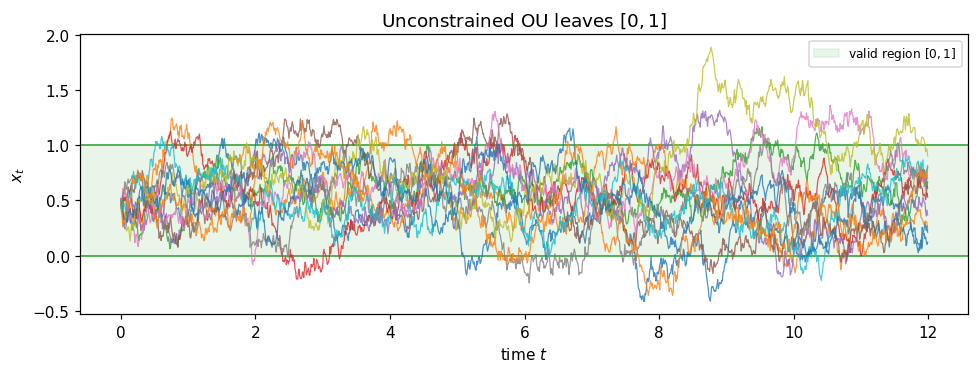

In [3]:
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.axhspan(0.0, 1.0, color="C2", alpha=0.10, label="valid region $[0, 1]$")
ax.axhline(0.0, color="C2", lw=1)
ax.axhline(1.0, color="C2", lw=1)
for path in unc_paths:
    ax.plot(times, path, lw=0.8, alpha=0.8)
ax.set(xlabel="time $t$", ylabel="$x_t$", title="Unconstrained OU leaves $[0, 1]$")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

## 2. Constrain it with WSP

We wrap the *same* OU evolution in `WSP`, passing the box $[0,1]$ and the WSP hyperparameters. The paper uses a stiff boundary ($\alpha=5,\ \beta=1000$) for a unit square; here we use a gentler $\beta$ so the transition is visible while the interior dynamics are essentially untouched.

In [4]:
box = Box(jnp.array([0.0]), jnp.array([1.0]))
ALPHA, BETA, GAMMA, EPS = 6.0, 25.0, 1.5, 0.05


def inner_ou():
    return ContinuousTimeStateEvolution(
        drift=ou_drift,
        diffusion=ScalarDiffusion(SIGMA, bm_dim=1),
    )


def ou_wsp(predict_times=None):
    model = DynamicalModel(
        initial_condition=initial_condition(),
        state_evolution=WSP(
            inner_ou(), box, alpha=ALPHA, beta=BETA, gamma=GAMMA, epsilon=EPS
        ),
        observation_model=obs_model(),
    )
    return dsx.sample("f", model, predict_times=predict_times)


with SDESimulator(source="em_scan", n_simulations=12):
    con = Predictive(ou_wsp, num_samples=1, exclude_deterministic=False)(
        jr.PRNGKey(0), predict_times=times
    )

con_paths = flatten_draws(con["f_states"])[:, :, 0]
print("unconstrained range:", float(unc_paths.min()), float(unc_paths.max()))
print("WSP-constrained range:", float(con_paths.min()), float(con_paths.max()))

unconstrained range: -0.41520383954048157 1.8890384435653687
WSP-constrained range: 0.0022173915058374405 0.9978098273277283


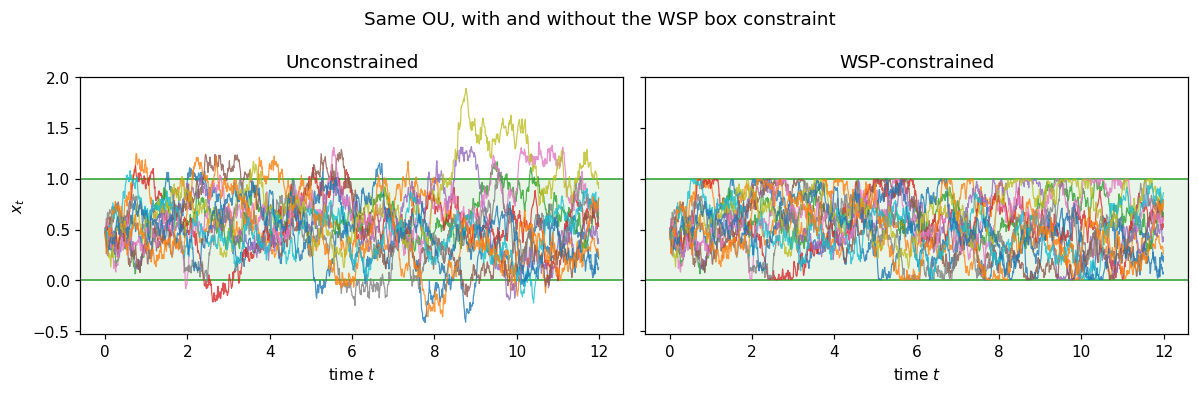

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for ax, paths, title in (
    (axes[0], unc_paths, "Unconstrained"),
    (axes[1], con_paths, "WSP-constrained"),
):
    ax.axhspan(0.0, 1.0, color="C2", alpha=0.10)
    ax.axhline(0.0, color="C2", lw=1)
    ax.axhline(1.0, color="C2", lw=1)
    for path in paths:
        ax.plot(times, path, lw=0.8, alpha=0.8)
    ax.set(xlabel="time $t$", title=title)
axes[0].set_ylabel("$x_t$")
fig.suptitle("Same OU, with and without the WSP box constraint")
plt.tight_layout()
plt.show()

## 3. Under the hood: weight, drift, and diffusion

WSP modifies the dynamics through the weight $w(x)$. Let's plot it, together with the unconstrained vs. WSP drift and the diffusion scale, across $[0, 1]$. Note how, near the faces, the WSP drift bends sharply inward and the diffusion collapses to zero — exactly the conditions that make the boundary unreachable.

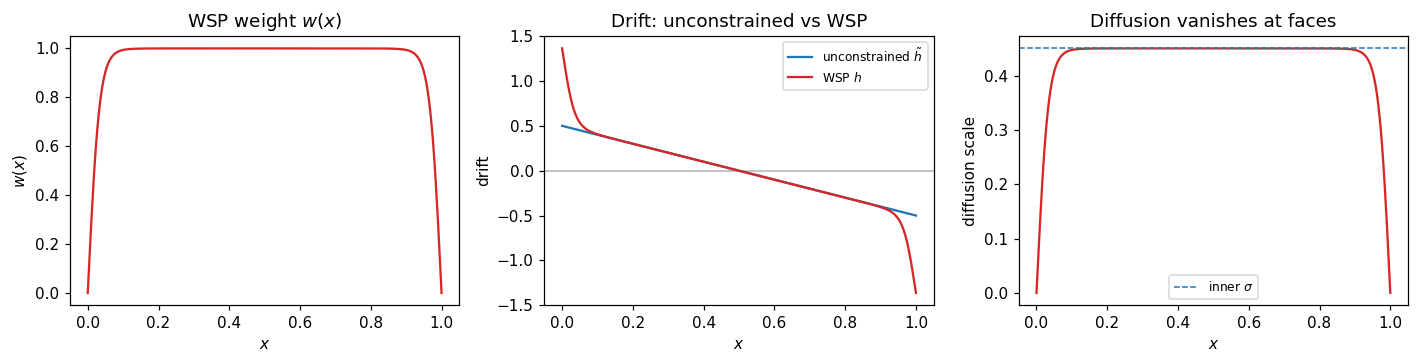

In [6]:
wsp_se = WSP(inner_ou(), box, alpha=ALPHA, beta=BETA, gamma=GAMMA, epsilon=EPS)

xs = jnp.linspace(0.0, 1.0, 300)[:, None]
w_vals = box.weight(xs, ALPHA, BETA)[:, 0]
unc_drift_vals = jax.vmap(lambda x: ou_drift(x, None, 0.0))(xs)[:, 0]
wsp_drift_vals = jax.vmap(lambda x: wsp_se.drift(x, None, 0.0))(xs)[:, 0]
diff_scale = jax.vmap(
    lambda x: wsp_se.diffusion.as_matrix(x=x, u=None, t=0.0, state_dim=1)
)(xs)[:, 0, 0]
xs1 = xs[:, 0]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
axes[0].plot(xs1, w_vals, color="C3")
axes[0].set(xlabel="$x$", ylabel="$w(x)$", title="WSP weight $w(x)$", ylim=(-0.05, 1.05))

axes[1].axhline(0.0, color="0.7", lw=1)
axes[1].plot(xs1, unc_drift_vals, label=r"unconstrained $\tilde h$", color="C0")
axes[1].plot(xs1, wsp_drift_vals, label="WSP $h$", color="C3")
axes[1].set(xlabel="$x$", ylabel="drift", title="Drift: unconstrained vs WSP")
axes[1].legend(fontsize=8)

axes[2].plot(xs1, diff_scale, color="C3")
axes[2].axhline(SIGMA, color="C0", ls="--", lw=1, label=r"inner $\sigma$")
axes[2].set(xlabel="$x$", ylabel="diffusion scale", title="Diffusion vanishes at faces")
axes[2].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 4. Parameter inference

WSP is just another `ContinuousTimeStateEvolution`, so the usual `dynestyx` inference machinery applies. We put a prior on the mean-reversion rate $\theta$, generate noisy observations from the WSP model at a known $\theta_\text{true}$, and recover it two ways: a **filter** (for the marginal likelihood and filtered states) and **stochastic variational inference**.

> **Why a particle filter here.** WSP's diffusion *vanishes at the boundary* ($g = \mathrm{diag}(w)\tilde L \to 0$ there). Gaussian filters that propagate and invert a state covariance — KF/EKF/UKF and even the ensemble Kalman filter — become singular when a state/ensemble member approaches a face (the process-noise covariance loses rank and its Cholesky factor blows up). A **particle filter** sidesteps this entirely: it propagates particles through the SDE via $L\,dW$ directly, so a vanishing $L$ simply means "no noise there" — nothing to invert. We use the continuous-time differentiable particle filter (`ContinuousTimeDPFConfig`) with a **fixed-step** Euler solver (no adaptive stepping), which keeps the marginal-likelihood estimate differentiable for SVI and the runtime predictable.

In [7]:
THETA_PRIOR = dist.Uniform(0.1, 4.0)
THETA_DATA = 1.5  # ground-truth used to generate the observations
obs_times = jnp.arange(0.0, 8.0, 0.1)  # 80 observations


def wsp_model(obs_times=None, obs_values=None, predict_times=None):
    theta = numpyro.sample("theta", THETA_PRIOR)
    inner = ContinuousTimeStateEvolution(
        drift=lambda x, u, t: theta * (MU - x),
        diffusion=ScalarDiffusion(SIGMA, bm_dim=1),
    )
    model = DynamicalModel(
        initial_condition=initial_condition(),
        state_evolution=WSP(inner, box, alpha=ALPHA, beta=BETA, gamma=GAMMA, epsilon=EPS),
        observation_model=obs_model(),
    )
    return dsx.sample(
        "f",
        model,
        obs_times=obs_times,
        obs_values=obs_values,
        predict_times=predict_times,
    )


# Generate a single noisy trajectory at theta = THETA_DATA.
gen = Predictive(
    wsp_model, params={"theta": jnp.array(THETA_DATA)}, num_samples=1,
    exclude_deterministic=False,
)
with SDESimulator(source="em_scan"):
    synth = gen(jr.PRNGKey(7), predict_times=obs_times)

obs_values = synth["f_observations"][0, 0]      # (T, 1)
latent_states = synth["f_states"][0, 0, :, 0]   # (T,)
print("obs shape:", obs_values.shape, "obs range:",
      float(obs_values.min()), float(obs_values.max()))


# A fixed-step (non-adaptive) particle filter, robust to the boundary-degenerate diffusion.
dpf = ContinuousTimeDPFConfig(
    n_particles=150,
    diffeqsolve_dt0=0.05,
    diffeqsolve_max_steps=32,
    diffeqsolve_kwargs={
        "solver": diffrax.Euler(),
        "stepsize_controller": diffrax.ConstantStepSize(),
    },
)

obs shape: (80, 1) obs range: -0.04491915553808212 0.9961917400360107


### 4a. Filtering

Wrapping the data-conditioned model in `Filter` adds the marginal log-likelihood $\log p(y_{1:T})$ as a `numpyro.factor` and records the filtered state estimates (here, the particle-weighted mean and variance).

/Users/danwaxman/Documents/dynestyx/dynestyx/inference/integrations/cd_dynamax/utils.py:135: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  return _CallableFunction(fn=value)


marginal log-likelihood: 51.587371826171875


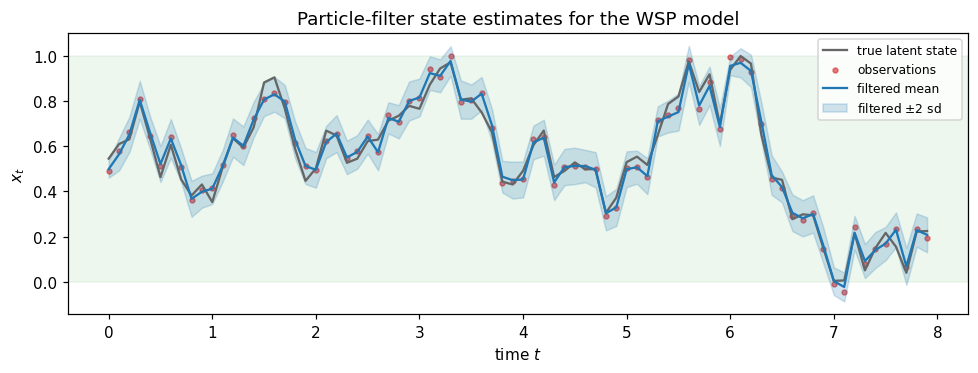

In [8]:
filt_dpf = ContinuousTimeDPFConfig(
    n_particles=150,
    diffeqsolve_dt0=0.05,
    diffeqsolve_max_steps=32,
    diffeqsolve_kwargs={
        "solver": diffrax.Euler(),
        "stepsize_controller": diffrax.ConstantStepSize(),
    },
    record_filtered_states_mean=True,
    record_filtered_states_cov_diag=True,
)


def filtered_model():
    with Filter(filter_config=dpf):
        return wsp_model(obs_times=obs_times, obs_values=obs_values)


def recording_model():
    with Filter(filter_config=filt_dpf):
        return wsp_model(obs_times=obs_times, obs_values=obs_values)


# Trace once at theta = THETA_DATA to read the marginal log-likelihood + filtered states.
tr = numpyro.handlers.trace(
    numpyro.handlers.substitute(
        numpyro.handlers.seed(recording_model, jr.PRNGKey(11)),
        {"theta": jnp.array(THETA_DATA)},
    )
).get_trace()
print("marginal log-likelihood:", float(tr["f_marginal_loglik"]["value"]))

filt_mean = tr["f_filtered_states_mean"]["value"][:, 0]
filt_sd = jnp.sqrt(tr["f_filtered_states_cov_diag"]["value"][:, 0])

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.axhspan(0.0, 1.0, color="C2", alpha=0.08)
ax.plot(obs_times, latent_states, color="0.4", lw=1.5, label="true latent state")
ax.scatter(obs_times, obs_values[:, 0], s=10, color="C3", alpha=0.6, label="observations")
ax.plot(obs_times, filt_mean, color="C0", lw=1.5, label="filtered mean")
ax.fill_between(obs_times, filt_mean - 2 * filt_sd, filt_mean + 2 * filt_sd,
                color="C0", alpha=0.2, label="filtered $\\pm 2$ sd")
ax.set(xlabel="time $t$", ylabel="$x_t$",
       title="Particle-filter state estimates for the WSP model")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

A quick **profile likelihood** over $\theta$ — evaluating the EnKF marginal log-likelihood on a grid — shows the data are informative about $\theta$, with a peak near the ground truth.

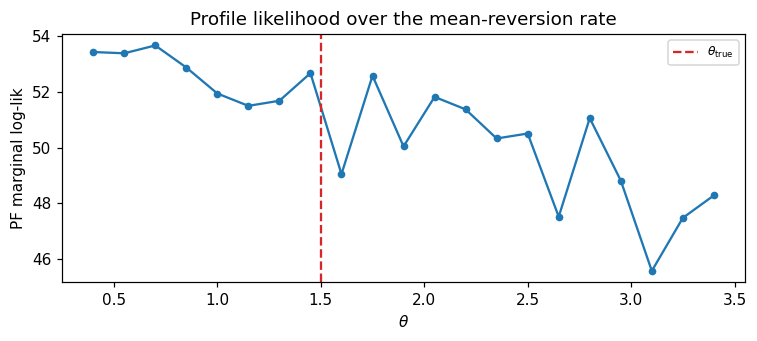

In [9]:
def marginal_loglik_at(theta_value, key):
    tr = numpyro.handlers.trace(
        numpyro.handlers.substitute(
            numpyro.handlers.seed(filtered_model, key), {"theta": theta_value}
        )
    ).get_trace()
    return tr["f_marginal_loglik"]["value"]


theta_grid = jnp.linspace(0.4, 3.4, 21)
keys = jr.split(jr.PRNGKey(21), theta_grid.shape[0])
# lax.map evaluates the grid sequentially (compiles once) to keep memory modest.
profile = jax.lax.map(lambda args: marginal_loglik_at(*args), (theta_grid, keys))

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(theta_grid, profile, "o-", ms=4, color="C0")
ax.axvline(THETA_DATA, color="C3", ls="--", label=r"$\theta_\mathrm{true}$")
ax.set(xlabel=r"$\theta$", ylabel="PF marginal log-lik",
       title="Profile likelihood over the mean-reversion rate")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### 4b. SVI

We now infer the posterior over $\theta$ with stochastic variational inference, using a standard NumPyro `AutoNormal` guide over the same particle-filter-conditioned model — no custom wrappers, just `dsx`'s `Filter` context inside the model. The differentiable PF makes the marginal-likelihood estimate differentiable, so `Trace_ELBO` gradients flow through to $\theta$.

theta posterior: mean=1.915, sd=0.381  (true 1.5)


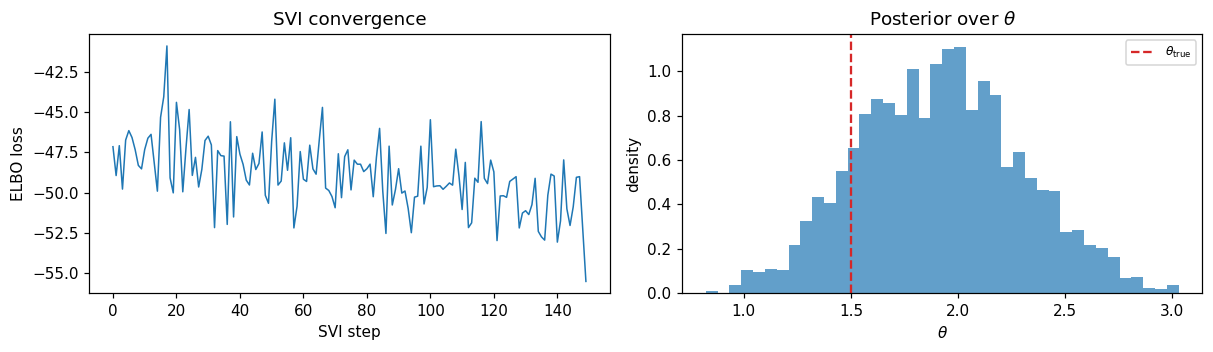

In [10]:
guide = AutoNormal(filtered_model)
svi = SVI(filtered_model, guide, optax.adam(3e-2), loss=Trace_ELBO())
svi_result = svi.run(jr.PRNGKey(31), 150, progress_bar=False)

posterior = guide.sample_posterior(
    jr.PRNGKey(32), svi_result.params, sample_shape=(3000,)
)
theta_post = posterior["theta"]
print(f"theta posterior: mean={float(theta_post.mean()):.3f}, "
      f"sd={float(theta_post.std()):.3f}  (true {THETA_DATA})")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.3))
axes[0].plot(svi_result.losses, color="C0", lw=1)
axes[0].set(xlabel="SVI step", ylabel="ELBO loss", title="SVI convergence")

axes[1].hist(theta_post, bins=40, density=True, color="C0", alpha=0.7)
axes[1].axvline(THETA_DATA, color="C3", ls="--", label=r"$\theta_\mathrm{true}$")
axes[1].set(xlabel=r"$\theta$", ylabel="density", title=r"Posterior over $\theta$")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

## Takeaways

- `dsx.WSP(state_evolution, dsx.Box(lower, upper))` turns any continuous-time SDE into one
  whose solution provably stays inside an axis-aligned box. Near the faces the diffusion
  vanishes and the drift points inward; in the interior the original dynamics are recovered.
- It is a drop-in `ContinuousTimeStateEvolution`, so simulation, filtering, and variational
  / MCMC inference all work unchanged. Here we recovered the mean-reversion rate with both a
  particle-filter profile likelihood and SVI; `NUTS` under the same `Filter` context works
  too (see `04_filtering_nuts_pseudomarginal.ipynb`).
- **Choose the filter with the boundary in mind.** WSP's diffusion is *degenerate at the
  boundary*, which makes covariance-propagating filters (KF / EKF / UKF / EnKF) singular
  there. A **particle filter** (`ContinuousTimeDPFConfig`) is the robust choice: it
  propagates particles through $L\,dW$, so a vanishing $L$ is harmless. Use a **fixed-step**
  solver (no adaptive stepping) for predictable, differentiable runs.
- **Practical notes.** Fixed-step solvers can nick a face; `clip=True` (default) plus a fine
  step keeps trajectories essentially contained. The coarse fixed-step filter introduces a
  mild discretization bias in the parameter posterior (above, $\theta$ concentrates a little
  high of the truth); finer steps, more particles, and more data tighten it. WSP currently
  targets single-trajectory / shared-domain models — per-member box domains under
  `dsx.plate` are not yet supported.